## Book Recommendation System

This project builds a system that recommends books. We build a popularity-based recommender (best books for everyone) and an item-based collaborative filtering recommender (books that are liked by the same readers), using a fast nearest neighbors search on a sparse matrix. The objective is in order to recommend books to a reader in two ways: the top books overall, and books similar to a book they liked.


## Approach
1. Load the data and explore it (rating distribution, ratings per book and per user, top authors)
2. Popularity-based recommender: rank books with a weighted rating, so books with few ratings do not dominate
3. Build a sparse book-user rating matrix (a dense table would be too large)
4. Item-based collaborative filtering: find similar books with cosine similarity and nearest neighbors
5. Test the recommender on well-known books and check if the suggestions make sense
6. (Optional) Compare with a simple author-based or genre-based suggestion
7. Publish an app using Streamlit

In [1]:
# Load the data
import pandas as pd

base = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master"
books = pd.read_csv(f"{base}/books.csv")
ratings = pd.read_csv(f"{base}/ratings.csv")

In [2]:
print(books.shape, ratings.shape)

(10000, 23) (5976479, 3)


In [3]:
books[["book_id", "title", "authors", "average_rating", "ratings_count"]].head()

,book_id,title,authors,average_rating,ratings_count
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34,4780653
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,4602479
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,3.57,3866839
3,4,To Kill a Mockingbird,Harper Lee,4.25,3198671
4,5,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664


In [4]:
ratings.sample(2)

,user_id,book_id,rating
3803657,43931,5455,4
1584411,22518,6144,4


In [5]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [6]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


In [7]:
ratings["rating"].value_counts().sort_index()

,count
rating,
1,124195
2,359257
3,1370916
4,2139018
5,1983093


In [8]:
ratings["book_id"].value_counts().sort_index()

,count
book_id,
1,22806
2,21850
3,16931
4,19088
5,16604
...,...
9996,141
9997,93
9998,102


In [9]:
# EDA
print(books.isnull().sum()[lambda s: s > 0])
print(ratings.isnull().sum().sum(), ratings.duplicated(["user_id", "book_id"]).sum())

isbn                          700
isbn13                        585
original_publication_year      21
original_title                585
language_code                1084
dtype: int64
0 0


<Axes: title={'center': 'Rating Distribution'}, xlabel='rating'>

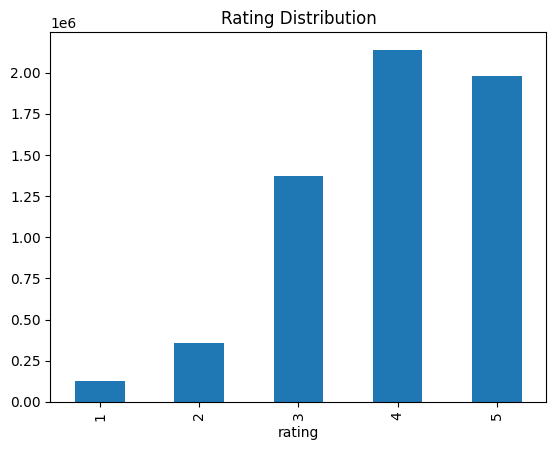

In [10]:
ratings["rating"].value_counts().sort_index().plot(kind="bar", title="Rating Distribution")

In [13]:
ratings.groupby("user_id").size().describe().round(1)     # kullanıcı başına puan sayısı

,0
count,53424.0
mean,111.9
std,26.1
min,19.0
25%,96.0
50%,111.0
75%,128.0
max,200.0


In [14]:
ratings.groupby("book_id").size().describe().round(1)     # kitap başına puan sayısı

,0
count,10000.0
mean,597.6
std,1267.3
min,8.0
25%,155.0
50%,248.0
75%,503.0
max,22806.0


In [15]:
books.nlargest(10, "ratings_count")[["title", "authors", "average_rating", "ratings_count"]]

,title,authors,average_rating,ratings_count
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34,4780653
1,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,4602479
2,"Twilight (Twilight, #1)",Stephenie Meyer,3.57,3866839
3,To Kill a Mockingbird,Harper Lee,4.25,3198671
4,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664
5,The Fault in Our Stars,John Green,4.26,2346404
6,The Hobbit,J.R.R. Tolkien,4.25,2071616
7,The Catcher in the Rye,J.D. Salinger,3.79,2044241
9,Pride and Prejudice,Jane Austen,4.24,2035490
8,"Angels & Demons (Robert Langdon, #1)",Dan Brown,3.85,2001311


In [16]:
books["authors"].value_counts().head(10)

,count
authors,
Stephen King,60
Nora Roberts,59
Dean Koontz,47
Terry Pratchett,42
Agatha Christie,39
Meg Cabot,37
James Patterson,36
David Baldacci,34
John Grisham,33


<Axes: title={'center': 'Average Rating of Books'}, ylabel='Frequency'>

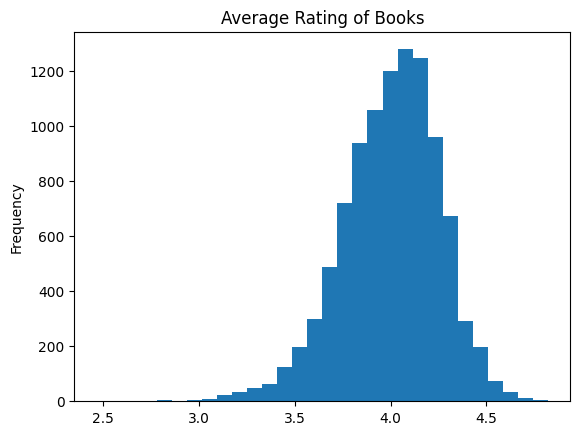

In [17]:
books["average_rating"].plot(kind="hist", bins=30, title="Average Rating of Books")

In [18]:
ratings = ratings.drop_duplicates(["user_id", "book_id"])

In [19]:
# Popularity-based recommender
stats = ratings.groupby("book_id")["rating"].agg(v="count", R="mean")
C = ratings["rating"].mean()                  # tüm kitapların genel ortalaması
m = stats["v"].quantile(0.90)                 # en az bu kadar puan alanlar güvenilir sayılır

stats["weighted"] = stats["v"] / (stats["v"] + m) * stats["R"] + m / (stats["v"] + m) * C

top = (books.set_index("book_id")[["title", "authors"]]
       .join(stats)
       .sort_values("weighted", ascending=False))

top.head(10).round(2)

,title,authors,v,R,weighted
book_id,,,,,
25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",15304,4.53,4.48
27,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",15081,4.44,4.41
24,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPré",15523,4.43,4.39
18,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck",15855,4.42,4.38
422,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,1915,4.66,4.38
192,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,3948,4.50,4.37
161,"The Return of the King (The Lord of the Rings,...",J.R.R. Tolkien,6331,4.42,4.35
31,The Help,Kathryn Stockett,12727,4.38,4.34
862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,1373,4.70,4.34


In [20]:
# Build a sparse book-user rating matrix
top.sort_values("R", ascending=False).head(10)[["title", "v", "R", "weighted"]].round(2)

,title,v,R,weighted
book_id,,,,
3628,The Complete Calvin and Hobbes,482,4.83,4.18
7947,ESV Study Bible,88,4.82,3.98
9566,Attack of the Deranged Mutant Killer Monster S...,147,4.77,4.01
6920,The Indispensable Calvin and Hobbes,214,4.77,4.05
8978,The Revenge of the Baby-Sat,176,4.76,4.03
6361,There's Treasure Everywhere: A Calvin and Hobb...,263,4.76,4.07
6590,The Authoritative Calvin and Hobbes: A Calvin ...,243,4.76,4.06
4483,It's a Magical World: A Calvin and Hobbes Coll...,384,4.75,4.12
3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",285,4.74,4.08


In [21]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

ratings = ratings.drop_duplicates(["user_id", "book_id"])

book_cat = ratings["book_id"].astype("category")
user_cat = ratings["user_id"].astype("category")

mat = csr_matrix((ratings["rating"], (book_cat.cat.codes, user_cat.cat.codes)))   # satır: kitap, sütun: kullanıcı
book_ids = book_cat.cat.categories.to_numpy()                                       # satır sırasına karşılık gelen book_id
print(mat.shape, f"{mat.nnz / (mat.shape[0] * mat.shape[1]):.2%} dolu")

(10000, 53424) 1.12% dolu


In [22]:
knn = NearestNeighbors(metric="cosine", algorithm="brute").fit(mat)

titles = books.set_index("book_id")["title"]

In [26]:
# Test
def recommend_books(title, n=10):
    book_id = books.loc[books["title"].str.contains(title, case=False, regex=False), "book_id"].iloc[0]
    row = int((book_ids == book_id).nonzero()[0][0])
    dist, idx = knn.kneighbors(mat[row], n_neighbors=n + 1)
    return pd.DataFrame({
        "title": titles.loc[book_ids[idx[0][1:]]].values,
        "similarity": (1 - dist[0][1:]).round(3),
    })

recommend_books("The Hobbit")

,title,similarity
0,The Fellowship of the Ring (The Lord of the Ri...,0.670
1,Harry Potter and the Sorcerer's Stone (Harry P...,0.525
2,1984,0.454
3,"The Lion, the Witch, and the Wardrobe (Chronic...",0.454
4,"The Two Towers (The Lord of the Rings, #2)",0.437
5,Animal Farm,0.431
6,"The Return of the King (The Lord of the Rings,...",0.430
7,Lord of the Flies,0.427
8,To Kill a Mockingbird,0.426
9,The Hitchhiker's Guide to the Galaxy (Hitchhik...,0.417


In [24]:
recommend_books("Gone Girl")

,title,similarity
0,The Girl on the Train,0.495
1,Dark Places,0.457
2,Sharp Objects,0.431
3,The Help,0.410
4,The Fault in Our Stars,0.402
5,"The Girl with the Dragon Tattoo (Millennium, #1)",0.398
6,"The Hunger Games (The Hunger Games, #1)",0.390
7,The Husband's Secret,0.370
8,The Goldfinch,0.362
9,Water for Elephants,0.361


In [25]:
recommend_books("Pride and Prejudice")

,title,similarity
0,Jane Eyre,0.579
1,Sense and Sensibility,0.566
2,"Little Women (Little Women, #1)",0.481
3,To Kill a Mockingbird,0.480
4,Emma,0.467
5,The Great Gatsby,0.466
6,Wuthering Heights,0.463
7,Romeo and Juliet,0.430
8,Harry Potter and the Sorcerer's Stone (Harry P...,0.429
9,Persuasion,0.412


In [27]:
# Preparation for Streamlit App
dist, idx = knn.kneighbors(mat, n_neighbors=11)

neighbors = pd.DataFrame({
    "book_id": book_ids.repeat(10),
    "neighbor_id": book_ids[idx[:, 1:]].ravel(),
    "similarity": (1 - dist[:, 1:]).ravel().round(4),
})

books_out = books[["book_id", "title", "authors", "average_rating"]].join(stats[["v", "weighted"]], on="book_id")

neighbors.to_csv("book_neighbors.csv", index=False)
books_out.to_csv("books_lite.csv", index=False)